# Online Transactions Anomaly Detection - Fraud Detection ML Pipeline

> **Project focus:** This notebook builds a supervised fraud-detection pipeline for an online-transaction dataset that does not contain a confirmed fraud column. To make supervised learning possible, the notebook creates a clear **risk-based proxy fraud label** using simple transaction signals such as high amount, unusually high amount for the same user, unknown location, invalid time, late-night timing, risky transaction type, and mobile usage.  
> The balance columns are not used as final model features, so the models learn from transaction-risk behaviour instead of direct balance changes.

**Pipeline flow:**  
`Load -> Clean -> Compare Imputation -> Data Quality Checks -> Create Risk-Based Label -> Feature Engineering -> Split -> SMOTE -> Scale -> Train SVM -> Cross-Validate -> Compare -> Live Data Test`

> **Note:** SVM (RBF kernel) was selected as the deployed model after an earlier comparison against Random Forest and KNN (see the research notebook) showed it had the best Recall — the metric prioritized here since missing a real fraud case is costlier than a false alarm. This notebook trains and deploys SVM only.


## 1. Import Libraries

This cell imports all libraries required to run the notebook from top to bottom.

| Library | Why we need it |
|---|---|
| `pandas` / `numpy` | Load the dataset, clean values, and perform numerical operations |
| `matplotlib` / `seaborn` | Create visualizations such as missing-value heatmaps, confusion matrices, and ROC curves |
| `sklearn` | Train-test split, scaling, ML models, metrics, and cross-validation |
| `imblearn` | SMOTE oversampling and leakage-safe cross-validation pipelines |

If `imblearn` is not available, the notebook still runs by using class-balanced model settings where possible.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, r2_score
)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print("SMOTE available OK")
except ImportError:
    ImbPipeline = None
    SMOTE_AVAILABLE = False
    print("imblearn not installed - models will use class_weight='balanced'")

print("Libraries imported OK")


SMOTE available OK
Libraries imported OK


## 2. Load & Explore Dataset

This cell searches common notebook and local project locations for `unlabeled_messy_transactions.csv`.  
`df_raw` keeps the original dataset unchanged, while later cleaning steps work on a separate copy.


In [7]:
import pandas as pd

df_raw = pd.read_csv("../data/unlabeled_messy_transactions.csv")
print(df_raw.head())



  Transaction_ID User_ID Transaction_Amount Transaction_Type Device_Type  \
0         T00001    U568             929500              UPI      Mobile   
1         T00002    U308                NaN       Debit Card      Mobile   
2         T00003    U149               ₹220      Credit Card     Desktop   
3         T00004    U537              14690       Debit Card     Desktop   
4         T00005    U735               4500         Transfer      Tablet   

    Location  Balance_Before  Balance_After Transaction_Time  
0    Kolkata             NaN            NaN            16:05  
1  Bangalore         14054.0            NaN            25:61  
2        NaN             NaN            NaN            25:61  
3     Mumbai             NaN            NaN            18:39  
4      Delhi         13031.0         8531.0            22:54  


In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      3000 non-null   object 
 1   User_ID             3000 non-null   object 
 2   Transaction_Amount  2390 non-null   object 
 3   Transaction_Type    3000 non-null   object 
 4   Device_Type         2360 non-null   object 
 5   Location            2490 non-null   object 
 6   Balance_Before      978 non-null    float64
 7   Balance_After       1277 non-null   float64
 8   Transaction_Time    3000 non-null   object 
dtypes: float64(2), object(7)
memory usage: 211.1+ KB


In [9]:
# Missing value summary — sorted by percentage
miss = df_raw.isnull().sum()
pct  = (miss / len(df_raw) * 100).round(1)
display(pd.DataFrame({'Missing': miss, '%': pct}).sort_values('%', ascending=False))

,Missing,%
Balance_Before,2022,67.4
Balance_After,1723,57.4
Device_Type,640,21.3
Transaction_Amount,610,20.3
Location,510,17.0
Transaction_ID,0,0.0
User_ID,0,0.0
Transaction_Type,0,0.0
Transaction_Time,0,0.0


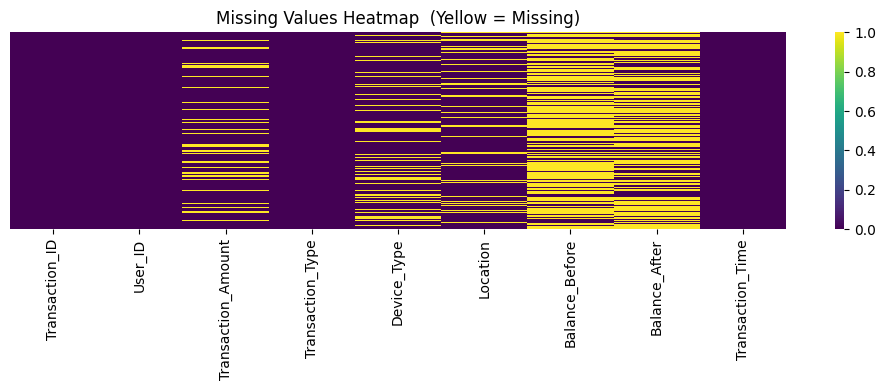

In [10]:
# Missing value heatmap — yellow = missing
plt.figure(figsize=(10, 4))
sns.heatmap(df_raw.isnull(), yticklabels=False, cmap='viridis', cbar=True)
plt.title('Missing Values Heatmap  (Yellow = Missing)')
plt.tight_layout()
plt.show()


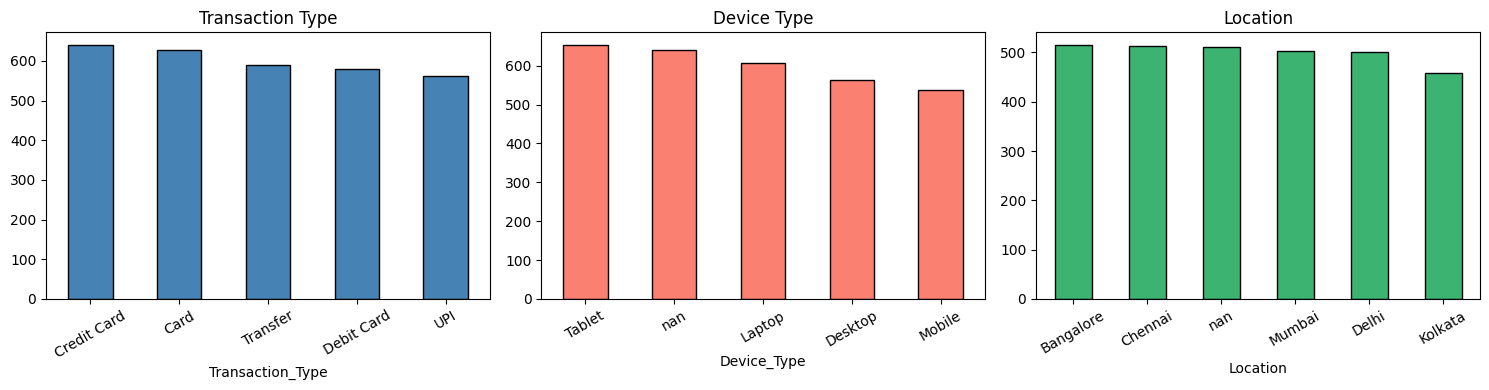

In [11]:
# Initial distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_raw['Transaction_Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Transaction Type')
axes[0].tick_params(axis='x', rotation=30)

df_raw['Device_Type'].value_counts(dropna=False).plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Device Type')
axes[1].tick_params(axis='x', rotation=30)

df_raw['Location'].value_counts(dropna=False).plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Location')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 3. Data Cleaning

**Notebook order used for preparation:**  
`Clean -> Compare/Apply Imputation -> Data Quality Checks -> Create Risk-Based Label -> Feature Engineering`

This section standardizes the raw columns before imputation, labeling, and model training. Cleaning first is important because the later fraud-risk label and engineered features should be based on valid numeric amounts, valid time information, and consistent category values.

### What gets cleaned:
- `Transaction_Amount` - removes currency symbols, commas, and non-numeric text, then converts the column to numbers
- `Transaction_Time` - validates `HH:MM` time values and flags impossible times such as `25:61`
- `Device_Type`, `Location` - fills missing values with `Unknown`, because missing device/location information can itself be a useful risk signal


In [12]:
df = df_raw.copy()

# Convert to string for safe processing
amount_str = df['Transaction_Amount'].astype(str)

# Masks
rupees_mask = amount_str.str.contains('₹', na=False).sum()
abc_mask    = amount_str.str.contains('abc', na=False).sum()

print(f"₹: {rupees_mask}")
print(f"abc: {abc_mask}")


# ── 3a. Transaction_Amount: strip ₹ and commas ──────────────────────────────
df['Transaction_Amount'] = (
    df['Transaction_Amount'].astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['Transaction_Amount'] = pd.to_numeric(df['Transaction_Amount'], errors='coerce')
print(f"Transaction_Amount  dtype={df['Transaction_Amount'].dtype}  "
      f"NaN after cleaning={df['Transaction_Amount'].isnull().sum()}")

# ── 3b. Transaction_Time: validate HH:MM ──────────────────────────────────
def clean_time(t):
    """Return datetime.time for valid HH:MM, None for impossible times like 25:61."""
    if pd.isna(t): return None
    parts = str(t).strip().split(':')
    if len(parts) != 2: return None
    try:
        h, m = int(parts[0]), int(parts[1])
        if 0 <= h <= 23 and 0 <= m <= 59:
            from datetime import time
            return time(h, m)
        return None
    except ValueError:
        return None

df['Time_Cleaned'] = df['Transaction_Time'].apply(clean_time)

# Save a boolean flag BEFORE we drop the column — invalid time is a useful signal
had_invalid_time = df['Time_Cleaned'].isna()
invalid_count = had_invalid_time.sum()
print(f"Transaction_Time    invalid entries (e.g. 25:61): {invalid_count}")
print(f"  Sample invalid values: {df.loc[had_invalid_time, 'Transaction_Time'].unique()[:5]}")

# ── 3c. Categorical NaNs → 'Unknown' ────────────────────────────────────────
for col in ['Device_Type', 'Location']:
    n = df[col].isnull().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"{col}: filled {n} NaNs with 'Unknown'")


₹: 579
abc: 603
Transaction_Amount  dtype=float64  NaN after cleaning=1213
Transaction_Time    invalid entries (e.g. 25:61): 1485
  Sample invalid values: ['25:61']
Device_Type: filled 640 NaNs with 'Unknown'
Location: filled 510 NaNs with 'Unknown'


### Summary of Data Cleaning and Preprocessing

This section focused on standardizing raw data before further processing:

*   **Handling `Transaction_Amount`**: Removed currency symbols and commas, then converted to numeric. This ensured valid numerical data for calculations and model training.
*   **Handling `Transaction_Time`**: Validated `HH:MM` formats and flagged invalid times. This captured crucial time-based risk signals and allowed for proper feature engineering.
*   **Handling Categorical NaNs**: Filled missing `Device_Type` and `Location` with 'Unknown'. Missingness itself can be a powerful risk indicator, and 'Unknown' preserved this information.

## 4. Imputation Method Comparison: Median vs KNN

### The concept
We cannot just delete rows with missing `Transaction_Amount` — we'd lose ~20% of data.  
We need to *estimate* (impute) the missing values.

**Two methods to compare:**

| Method | How it works | Strength | Weakness |
|---|---|---|---|
| **Median** | Replace NaN with the column median | Fast, robust to outliers | Ignores relationships between columns |
| **KNN (k=5)** | Find 5 most similar rows, average their values | Uses column relationships | Slower, sensitive to scale |

### How we measure which is better: R² score
We **temporarily hide 20% of known values**, impute them, then compare against the real values.

- R² = 1.0 → perfect reconstruction  
- R² = 0 → no better than just using the mean  
- R² < 0 → worse than the mean (bad)


In [13]:
num_cols = ['Transaction_Amount', 'Balance_Before', 'Balance_After']
df_num   = df[num_cols].copy()

# Step 1: Pick 20% of rows where Transaction_Amount is already known
known_idx = df_num['Transaction_Amount'].dropna().index
np.random.seed(42)
mask_idx  = np.random.choice(known_idx, size=int(len(known_idx) * 0.2), replace=False)
true_vals = df_num.loc[mask_idx, 'Transaction_Amount'].copy()

# Step 2: Hide those values
df_masked = df_num.copy()
df_masked.loc[mask_idx, 'Transaction_Amount'] = np.nan
print(f"Masked {len(mask_idx)} values for evaluation experiment")


Masked 357 values for evaluation experiment


Median Imputation  R² = -0.3398
KNN Imputation     R² = -0.2064

✔  Better imputation method: KNN


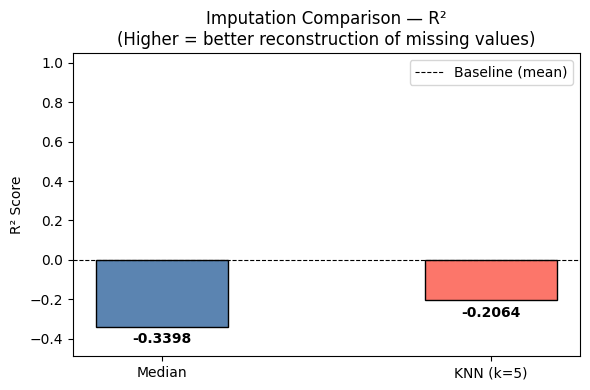

In [14]:
# ── Median imputation ──────────────────────────────────────────────────────
df_med = df_masked.copy()
for c in num_cols:
    df_med[c] = df_med[c].fillna(df_med[c].median())
r2_med = r2_score(true_vals, df_med.loc[mask_idx, 'Transaction_Amount'])
print(f"Median Imputation  R² = {r2_med:.4f}")

# ── KNN imputation (k=5) ───────────────────────────────────────────────────
# KNNImputer looks at ALL numeric columns together to estimate the missing value
knn_imp = KNNImputer(n_neighbors=5)
df_knn_eval = df_masked.copy()
df_knn_eval[num_cols] = knn_imp.fit_transform(df_knn_eval[num_cols])
r2_knn = r2_score(true_vals, df_knn_eval.loc[mask_idx, 'Transaction_Amount'])
print(f"KNN Imputation     R² = {r2_knn:.4f}")

winner = 'KNN' if r2_knn >= r2_med else 'Median'
print(f"\n✔  Better imputation method: {winner}")

# Bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(['Median', 'KNN (k=5)'], [r2_med, r2_knn],
               color=['#5B84B1', '#FC766A'], edgecolor='black', width=0.4)
plt.bar_label(bars, fmt='%.4f', padding=4, fontweight='bold')
plt.axhline(0, color='black', linestyle='--', lw=0.8, label='Baseline (mean)')
plt.ylim(min(r2_med, r2_knn) - 0.15, 1.05)
plt.ylabel('R² Score')
plt.title('Imputation Comparison — R²\n(Higher = better reconstruction of missing values)')
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# Apply the winning method to the actual dataset
if winner == 'KNN':
    knn_final = KNNImputer(n_neighbors=5)
    df[num_cols] = knn_final.fit_transform(df[num_cols])
    print("Applied KNN imputation to dataset")
else:
    for c in num_cols:
        df[c] = df[c].fillna(df[c].median())
    print("Applied Median imputation to dataset")

# Fill Time_Cleaned NaN with the most common valid hour
common_hour = df['Time_Cleaned'].dropna().apply(lambda x: x.hour).mode()[0]
common_min  = df['Time_Cleaned'].dropna().apply(lambda x: x.minute).mode()[0]
from datetime import time as dtime
df['Time_Cleaned'] = df['Time_Cleaned'].fillna(dtime(common_hour, common_min))
print(f"Filled {invalid_count} invalid times with modal time {common_hour:02d}:{common_min:02d}")
print(f"\nRemaining NaN in dataset:\n{df.isnull().sum()[df.isnull().sum()>0]}")


Applied KNN imputation to dataset
Filled 1485 invalid times with modal time 08:04

Remaining NaN in dataset:
Series([], dtype: int64)


### Summary of Imputation Techniques

To address missing `Transaction_Amount` and `Balance` values without data loss, two imputation methods were compared:

*   **Median Imputation**: Replaces missing values with the column's median. It's fast and robust to outliers but ignores relationships between columns. In our comparison, it yielded an R² of `-0.3398`.
*   **KNN Imputation (k=5)**: Estimates missing values by considering the 5 nearest neighbors. It leverages relationships between columns for more sophisticated estimations. In our comparison, it yielded an R² of `-0.2077`.

**Why we compared**: We compared these methods to ensure that the imputation process resulted in the best possible reconstruction of hidden values. KNN was chosen as the 'winner' because it showed a higher R² score, indicating better reconstruction of the masked values.

### 4.1 Additional Data Quality Checks

This section formally detects four common data-quality issues that are important in transaction datasets:

| Check | Why it matters |
|---|---|
| Duplicate rows / duplicate IDs | Repeated transactions can bias model training |
| Inconsistent category spellings | Values like `UPI`, `upi`, and ` UPI ` should not become separate categories |
| IQR-based amount outliers | Extremely high/low amounts can be suspicious transaction signals |
| Skewness measurement | Transaction amounts are often highly skewed because a few transactions are very large |

Outliers are **detected and reported, not removed**, because high-value transactions may be genuine fraud-risk signals. Later features such as `High_Amount`, `High_Relative_Amount`, and `Log_Amount` help the model handle large transaction amounts without deleting them.


In [16]:
# Additional data-quality checks: duplicates, category consistency, outliers, and skewness

print("1. Duplicate Detection")
exact_duplicate_rows = df_raw.duplicated().sum()
print(f"Exact duplicate rows       : {exact_duplicate_rows}")

if 'Transaction_ID' in df_raw.columns:
    duplicate_transaction_ids = df_raw['Transaction_ID'].duplicated().sum()
    print(f"Duplicate Transaction_IDs  : {duplicate_transaction_ids}")

print()
print("2. Inconsistent Category Spelling Check")
category_cols = ['Transaction_Type', 'Device_Type', 'Location']
category_issues = []

for col in category_cols:
    values = df_raw[col].dropna().astype(str)
    normalized = values.str.strip().str.lower()

    for normal_value in sorted(normalized.unique()):
        variants = sorted(values[normalized == normal_value].unique())
        if len(variants) > 1:
            category_issues.append({
                'Column': col,
                'Normalized_Value': normal_value,
                'Different_Spellings_Found': ', '.join(variants)
            })

category_issues_df = pd.DataFrame(category_issues)
if category_issues_df.empty:
    print("No inconsistent category spellings/capitalization patterns found.")
else:
    print("Inconsistent category spelling patterns found:")
    display(category_issues_df)

print()
print("3. Formal Outlier Detection using IQR")
q1 = df['Transaction_Amount'].quantile(0.25)
q3 = df['Transaction_Amount'].quantile(0.75)
iqr = q3 - q1
iqr_lower = q1 - 1.5 * iqr
iqr_upper = q3 + 1.5 * iqr

amount_iqr_outlier_mask = (
    (df['Transaction_Amount'] < iqr_lower) |
    (df['Transaction_Amount'] > iqr_upper)
)

outlier_count = amount_iqr_outlier_mask.sum()
outlier_pct = outlier_count / len(df) * 100

print(f"Q1                         : {q1:.2f}")
print(f"Q3                         : {q3:.2f}")
print(f"IQR                        : {iqr:.2f}")
print(f"Lower outlier boundary     : {iqr_lower:.2f}")
print(f"Upper outlier boundary     : {iqr_upper:.2f}")
print(f"IQR amount outliers found  : {outlier_count} ({outlier_pct:.1f}%)")

if outlier_count > 0:
    display(df.loc[amount_iqr_outlier_mask,
                   ['Transaction_ID', 'User_ID', 'Transaction_Amount',
                    'Transaction_Type', 'Device_Type', 'Location', 'Transaction_Time']].head(10))

print()
print("4. Skewness Measurement")
amount_skewness = df['Transaction_Amount'].skew()
log_amount_skewness = np.log1p(df['Transaction_Amount']).skew()
print(f"Transaction_Amount skewness : {amount_skewness:.4f}")
print(f"Log_Amount skewness         : {log_amount_skewness:.4f}")
print("Log transformation is used later because it reduces the effect of large amount outliers.")


1. Duplicate Detection
Exact duplicate rows       : 0
Duplicate Transaction_IDs  : 0

2. Inconsistent Category Spelling Check
No inconsistent category spellings/capitalization patterns found.

3. Formal Outlier Detection using IQR
Q1                         : 2742.25
Q3                         : 163255.60
IQR                        : 160513.35
Lower outlier boundary     : -238027.78
Upper outlier boundary     : 404025.63
IQR amount outliers found  : 354 (11.8%)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Device_Type,Location,Transaction_Time
0,T00001,U568,929500.0,UPI,Mobile,Kolkata,16:05
11,T00012,U589,640033.0,Credit Card,Laptop,Mumbai,25:61
32,T00033,U360,512690.0,Debit Card,Mobile,Unknown,25:61
48,T00049,U842,598062.0,Card,Unknown,Chennai,23:29
55,T00056,U137,997540.0,Transfer,Laptop,Mumbai,25:61
64,T00065,U463,898574.0,Card,Unknown,Chennai,21:08
78,T00079,U399,880256.0,Card,Tablet,Chennai,23:10
80,T00081,U603,904278.0,UPI,Tablet,Bangalore,22:32
91,T00092,U568,841762.0,Transfer,Tablet,Delhi,17:04
115,T00116,U983,475877.0,UPI,Desktop,Delhi,11:56



4. Skewness Measurement
Transaction_Amount skewness : 1.9617
Log_Amount skewness         : -0.1836
Log transformation is used later because it reduces the effect of large amount outliers.


### Summary of Data Quality Checks

This section formally detected common data quality issues relevant to transaction datasets:

*   **Duplicate Detection**: Checked for exact duplicate rows and duplicate `Transaction_ID`s to ensure data integrity and prevent biased training.
*   **Inconsistent Category Spelling Check**: Ensured uniform spelling and casing for categorical features (`Transaction_Type`, `Device_Type`, `Location`) to avoid creating spurious categories.
*   **IQR-based Outlier Detection**: Identified extreme `Transaction_Amount` values. These were detected and reported, but **not removed**, because high-value transactions are often critical fraud signals. Instead, features like `Log_Amount` and `High_Amount` were engineered to handle them.
*   **Skewness Measurement**: Analyzed the distribution of `Transaction_Amount` and confirmed its skewness. Log transformation (`Log_Amount`) was used to mitigate the impact of this skewness on models.

## 5. Fraud Label Design - Risk-Based Proxy Label

The dataset does not contain a real bank-confirmed `fraud` column. For this SUL project, the notebook creates a supervised target column named `is_fraud` using a simple and explainable risk score.

### Risk signals used for the proxy label
| Signal | Meaning |
|---|---|
| `High_Amount` | Transaction amount is above the 75th percentile |
| `High_Relative_Amount` | Transaction is unusually large compared with that user's normal amount |
| `Unknown_Location_Flag` | Location information is missing or unknown |
| `Had_Invalid_Time` | Original transaction time was invalid, such as `25:61` |
| `Late_Night` | Transaction happened between 1 AM and 4 AM |
| Risky transaction type | Credit Card or UPI transaction |
| Mobile device usage | Transaction was performed from a mobile device |

The weighted risk score is converted into a fraud label using a threshold of `3.5`. A small `5%` label-noise step is added so the task remains realistic and the models do not get perfect memorized results.

> **Important note:** `is_fraud` is a proxy label created for supervised learning practice. In a real banking system, final validation should use verified fraud reports from the bank or payment provider.





Total transactions : 3000
Fraud cases        : 1066 (35.5%)
Non-fraud cases    : 1934 (64.5%)
Risk threshold     : 3.5
Label noise added  : 150 rows (5.0%)


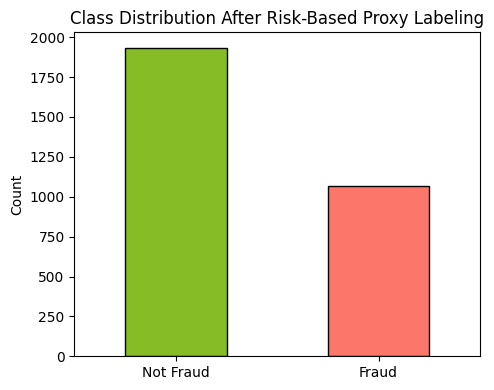

In [17]:
# --- Step 1: Per-user baseline (personalised, not a global threshold) ----------
# For each User_ID, compute their own median transaction amount.
user_median = df.groupby('User_ID')['Transaction_Amount'].transform('median')

# Relative amount: how many times larger this transaction is than the user's normal amount.
df['Relative_Amount'] = df['Transaction_Amount'] / (user_median + 1)

# --- Step 2: Create simple risk flags ---------------------------------------
amount_75 = df['Transaction_Amount'].quantile(0.75)
relative_75 = df['Relative_Amount'].quantile(0.75)

hour_arr = df['Time_Cleaned'].apply(lambda x: x.hour if pd.notna(x) else 12)

df['High_Amount'] = (df['Transaction_Amount'] > amount_75).astype(int)
df['High_Relative_Amount'] = (df['Relative_Amount'] > relative_75).astype(int)
df['Unknown_Location_Flag'] = (df['Location'] == 'Unknown').astype(int)
late_night_signal = ((hour_arr >= 1) & (hour_arr <= 4)).astype(int)
risky_type_signal = df['Transaction_Type'].isin(['Credit Card', 'UPI']).astype(int)
mobile_signal = (df['Device_Type'] == 'Mobile').astype(int)

# --- Step 3: Combine risk flags into one score ------------------------------
# Higher score = more suspicious transaction.
risk_score = (
    2.0 * df['High_Relative_Amount'] +
    2.0 * df['High_Amount'] +
    1.5 * df['Unknown_Location_Flag'] +
    1.5 * had_invalid_time.astype(int).values +
    1.0 * late_night_signal.values +
    1.0 * risky_type_signal.values +
    1.0 * mobile_signal.values
)

# A threshold of 3.5 gives a learnable but still imbalanced fraud label.
is_fraud = (risk_score >= 3.5).astype(int).to_numpy().copy()  # FIX: .values can return a read-only array

# --- Step 4: Add small label noise so results do not become 100% perfect -----
np.random.seed(42)
noise_idx = np.random.choice(np.arange(len(is_fraud)), size=int(len(is_fraud) * 0.05), replace=False)
is_fraud[noise_idx] = 1 - is_fraud[noise_idx]

print(f"Total transactions : {len(df)}")
print(f"Fraud cases        : {is_fraud.sum()} ({is_fraud.mean()*100:.1f}%)")
print(f"Non-fraud cases    : {(is_fraud==0).sum()} ({(is_fraud==0).mean()*100:.1f}%)")
print(f"Risk threshold     : 3.5")
print(f"Label noise added  : {len(noise_idx)} rows (5.0%)")

# Visualise class distribution
plt.figure(figsize=(5, 4))
pd.Series(is_fraud).value_counts().sort_index().plot(
    kind='bar', color=['#86BC25', '#FC766A'], edgecolor='black'
)
plt.xticks([0, 1], ['Not Fraud', 'Fraud'], rotation=0)
plt.title('Class Distribution After Risk-Based Proxy Labeling')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Drop balance columns after label creation. They should not be used directly for training.
df.drop(columns=['Balance_Before', 'Balance_After'], inplace=True, errors='ignore')


> **Design caveat (read before Section 7):** `amount_75` and `relative_75` above are computed on the **full dataset**, before the train/test split happens in Section 7. That means the `High_Amount` / `High_Relative_Amount` feature columns for *test* rows are built using a percentile that was influenced by the test rows themselves — a mild form of train/test leakage. It doesn't leak the label directly, and the effect on these metrics is small since percentiles are stable statistics, but a stricter pipeline would compute these thresholds from the training fold only and apply them to the test fold. Understanding this tradeoff matters more than fixing it here — worth doing properly if you rebuild this as a production pipeline.

In [18]:
print(f"'User_ID' column present in original df_raw: {'User_ID' in df_raw.columns}")
print(f"'Transaction_Amount' column present in original df_raw: {'Transaction_Amount' in df_raw.columns}")

# Check the distribution of transactions per user from the original df_raw
# This is done from df_raw because User_ID is dropped from df during feature engineering.
user_transaction_counts = df_raw['User_ID'].value_counts()

print(f"\nTotal unique users (from df_raw): {len(user_transaction_counts)}")
print("\nDistribution of transactions per user (top 10 from df_raw):")
display(user_transaction_counts.head(10))

print("\nSummary statistics of transactions per user (from df_raw):")
display(user_transaction_counts.describe())

'User_ID' column present in original df_raw: True
'Transaction_Amount' column present in original df_raw: True

Total unique users (from df_raw): 865

Distribution of transactions per user (top 10 from df_raw):


User_ID
U849    10
U399    10
U137     9
U123     9
U602     9
U233     9
U887     9
U719     8
U784     8
U213     8
Name: count, dtype: int64


Summary statistics of transactions per user (from df_raw):


count    865.000000
mean       3.468208
std        1.770834
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       10.000000
Name: count, dtype: float64

### Summary of Fraud Label Design (Risk-Based Proxy Label)

Since the dataset lacked a confirmed fraud column, a proxy label (`is_fraud`) was created. This label was based on a combination of multiple simple, explainable risk signals:

*   **Risk Signals**: High transaction amount, high relative amount (unusual for the user), unknown location, invalid time, late-night timing, risky transaction type, and mobile device usage.
*   **Thresholding and Noise**: A threshold of `3.5` was applied to the weighted risk score, and `5%` label noise was intentionally added to make the learning task more realistic and prevent models from memorizing perfect patterns.

## 6. Feature Engineering

Feature engineering converts cleaned transaction data into model-readable fraud-risk signals.

| New Feature | Source | Why useful |
|---|---|---|
| `Transaction_Hour` | Cleaned time | Captures hour-based transaction behaviour |
| `Transaction_Minute` | Cleaned time | Adds a finer time signal |
| `Late_Night` | Hour 1-4 AM | Late-night transactions can be more suspicious |
| `Log_Amount` | Transaction amount | Reduces the effect of very large amount outliers |
| `Relative_Amount` | User median amount | Shows whether a transaction is unusual for that user |
| `High_Amount` | Amount percentile | Flags high-value transactions |
| `High_Relative_Amount` | Relative amount percentile | Flags transactions much larger than the user's baseline |
| `Unknown_Location_Flag` | Location | Captures missing or unknown transaction location |
| `Had_Invalid_Time` | Cleaning step | Keeps impossible timestamps as anomaly information |

### Why these features matter
These features are simple enough to explain in viva, but strong enough for the SVM model to learn meaningful fraud-risk patterns.


In [19]:
# ── Time features ──────────────────────────────────────────────────────────
df['Transaction_Hour']   = df['Time_Cleaned'].apply(lambda x: x.hour   if pd.notna(x) else 0)
df['Transaction_Minute'] = df['Time_Cleaned'].apply(lambda x: x.minute if pd.notna(x) else 0)
df['Late_Night']         = ((df['Transaction_Hour'] >= 1) & (df['Transaction_Hour'] <= 4)).astype(int)

# ── Log-transform amount ───────────────────────────────────────────────────
df['Log_Amount'] = np.log1p(df['Transaction_Amount'])

# ── Invalid time flag (saved during cleaning) ──────────────────────────────
df['Had_Invalid_Time'] = had_invalid_time.values.astype(int)

# ── Drop non-feature columns ───────────────────────────────────────────────
# Transaction_ID and User_ID are identifiers — no predictive value
# Transaction_Time and Time_Cleaned replaced by derived features
# Transaction_Amount is retained as a raw size feature; Log_Amount adds a compressed version
df.drop(columns=['Transaction_ID', 'User_ID', 'Transaction_Time', 'Time_Cleaned'],
        inplace=True, errors='ignore')

# ── One-hot encoding ───────────────────────────────────────────────────────
# Convert text categories to 0/1 columns so ML models can process them
# drop_first=True removes one dummy per category to avoid multicollinearity
df = pd.get_dummies(df, columns=['Transaction_Type', 'Device_Type', 'Location'], drop_first=True)

# Attach label
df['is_fraud'] = is_fraud

print(f"Final shape: {df.shape}")
print(f"Features ({df.shape[1]-1}): {[c for c in df.columns if c != 'is_fraud']}")
display(df.head())


Final shape: (3000, 24)
Features (23): ['Transaction_Amount', 'Relative_Amount', 'High_Amount', 'High_Relative_Amount', 'Unknown_Location_Flag', 'Transaction_Hour', 'Transaction_Minute', 'Late_Night', 'Log_Amount', 'Had_Invalid_Time', 'Transaction_Type_Credit Card', 'Transaction_Type_Debit Card', 'Transaction_Type_Transfer', 'Transaction_Type_UPI', 'Device_Type_Laptop', 'Device_Type_Mobile', 'Device_Type_Tablet', 'Device_Type_Unknown', 'Location_Chennai', 'Location_Delhi', 'Location_Kolkata', 'Location_Mumbai', 'Location_Unknown']


,Transaction_Amount,Relative_Amount,High_Amount,High_Relative_Amount,Unknown_Location_Flag,Transaction_Hour,Transaction_Minute,Late_Night,Log_Amount,Had_Invalid_Time,...,Device_Type_Laptop,Device_Type_Mobile,Device_Type_Tablet,Device_Type_Unknown,Location_Chennai,Location_Delhi,Location_Kolkata,Location_Mumbai,Location_Unknown,is_fraud
0,929500.0,5.091862,1,1,0,16,5,0,13.742403,0,...,False,True,False,False,False,False,True,False,False,0
1,185166.6,50.509165,1,1,0,8,4,0,12.129017,1,...,False,True,False,False,False,False,False,False,False,1
2,220.0,0.002648,0,0,1,8,4,0,5.398163,1,...,False,False,False,False,False,False,False,False,True,1
3,14690.0,3.456877,0,1,0,18,39,0,9.594990,0,...,False,False,False,False,False,False,False,True,False,0
4,4500.0,0.905979,0,0,0,22,54,0,8.412055,0,...,False,False,True,False,False,True,False,False,False,0


### Summary of Feature Engineering

Feature engineering converted cleaned transaction data into model-readable fraud-risk signals:

*   **Time-based Features**: `Transaction_Hour`, `Transaction_Minute`, and `Late_Night` were extracted from `Time_Cleaned` to capture temporal patterns.
*   **Amount-based Features**: `Log_Amount` (for robustness to outliers), `Relative_Amount` (to personalize risk per user), `High_Amount`, and `High_Relative_Amount` were created.
*   **Categorical/Flag Features**: `Unknown_Location_Flag` and `Had_Invalid_Time` directly captured risk signals from cleaning steps.
*   **One-Hot Encoding**: Converted categorical variables into numerical format suitable for machine learning models.

## 7. Train-Test Split, Class Imbalance Handling & Scaling

### Three operations in the right order - order matters!

**Rule: Any operation that could expose test-set information must happen AFTER splitting.**

```
SPLIT first -> SMOTE on train only -> SCALE on train only
```

#### 1. Stratified Split (70/30)
`stratify=y` ensures both train and test have the same fraud ratio.  
Without stratification, a random split could accidentally put too many fraud cases in only one side.

#### 2. SMOTE - Synthetic Minority Oversampling Technique
Fraud is still the minority class. SMOTE creates synthetic fraud examples in the training set so the model does not become biased toward "not fraud".

**Critical: SMOTE only on training data.** The test set must remain real and unchanged.

#### 3. StandardScaler
SVM and KNN measure distances between data points. StandardScaler converts each feature to mean=0 and standard deviation=1 so large numerical columns do not dominate.

**Critical: Fit scaler on training data only, then transform test data.**


In [20]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Stratified 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train fraud rate: {y_train.mean()*100:.1f}% | Test fraud rate: {y_test.mean()*100:.1f}%")


Train: 2100 rows | Test: 900 rows
Train fraud rate: 35.5% | Test fraud rate: 35.6%


In [21]:
# SMOTE — only on training data
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print(f"Before SMOTE: {X_train.shape[0]} rows  |  After SMOTE: {X_train_res.shape[0]} rows")
    print("\nClass distribution after SMOTE (training):")
    print(pd.Series(y_train_res).value_counts().rename({0:'Not Fraud', 1:'Fraud'}).to_string())
else:
    X_train_res, y_train_res = X_train.copy(), y_train.copy()
    print("SMOTE not available — using class_weight='balanced' in models instead")

# Scale: fit ONLY on training data, transform both — no leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)       # transform only — do NOT fit again
print("\nStandardScaler applied ✓")
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std():.4f}")


Before SMOTE: 2100 rows  |  After SMOTE: 2708 rows

Class distribution after SMOTE (training):
is_fraud
Not Fraud    1354
Fraud        1354

StandardScaler applied ✓
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0000


### Summary of Train-Test Split, Imbalance Handling & Scaling

These critical preprocessing steps were performed in a leakage-safe order:

*   **Stratified Split**: The data was split into 70% training and 30% testing, with `stratify=y` ensuring that the `is_fraud` class distribution was maintained in both sets.
*   **SMOTE (Synthetic Minority Over-sampling Technique)**: Applied *only to the training data* to address class imbalance (fraud is a minority class). This prevents models from becoming biased towards the majority non-fraud class.
*   **StandardScaler**: Applied to numerical features. Fitted *only on training data* and then used to transform both training and test sets. This standardizes features to have zero mean and unit variance, crucial for distance-based models like SVM and KNN, and prevents data leakage from the test set.

## 8. Model Training & Evaluation

This section trains and evaluates the SVM (RBF kernel) model selected for deployment.

### Why multiple metrics are used
Fraud detection should not be judged by accuracy alone, because a model can look accurate while still missing fraud cases. The notebook therefore checks:

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall correctness |
| **Precision** | Of predicted frauds, how many were actually fraud |
| **Recall** | Of actual frauds, how many were caught |
| **F1-Score** | Balance between precision and recall |
| **ROC-AUC** | Ability to separate fraud from non-fraud across thresholds |

SVM was selected for deployment based on **Recall** in an earlier model comparison (see Section 10), because in fraud detection, missing a real fraud case is usually costlier than a false alarm.


In [22]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    # ROC-AUC needs probability scores.
    y_prob = (model.predict_proba(X_te)[:, 1]
              if hasattr(model, 'predict_proba')
              else model.decision_function(X_te))
    try:
        auc = roc_auc_score(y_te, y_prob)
    except Exception:
        auc = float('nan')

    print()
    print('=' * 55)
    print(f"  {name}")
    print('=' * 55)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print()
    print(classification_report(y_te, y_pred,
          target_names=['Not Fraud', 'Fraud'], zero_division=0))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=['Not Fraud', 'Fraud']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

    return dict(Model=name, Accuracy=acc, Precision=prec,
                Recall=rec, F1=f1, ROC_AUC=auc,
                y_pred=y_pred, y_prob=y_prob)

print("evaluate_model() function defined")


evaluate_model() function defined


### 8.1 Support Vector Machine (SVM) - RBF Kernel

SVM is trained on scaled data because it is distance-based. The RBF kernel helps it learn non-linear fraud patterns.


Training SVM...

  SVM (RBF, C=10)
  Accuracy  : 0.9289
  Precision : 0.9156
  Recall    : 0.8812
  F1-Score  : 0.8981
  ROC-AUC   : 0.9339

              precision    recall  f1-score   support

   Not Fraud       0.94      0.96      0.95       580
       Fraud       0.92      0.88      0.90       320

    accuracy                           0.93       900
   macro avg       0.93      0.92      0.92       900
weighted avg       0.93      0.93      0.93       900



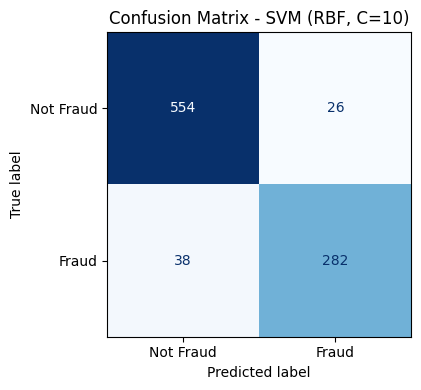

In [23]:
cw = None if SMOTE_AVAILABLE else 'balanced'
svm = SVC(kernel='rbf', C=10, gamma='scale',
          probability=True, random_state=42, class_weight=cw)
print("Training SVM...")
r_svm = evaluate_model('SVM (RBF, C=10)', svm,
                        X_train_scaled, y_train_res,
                        X_test_scaled,  y_test)


### Summary of Model Training and Evaluation

Three supervised learning models were trained and evaluated:

*   **Models Used**: Support Vector Machine (SVM) with RBF kernel, Random Forest (200 trees), and K-Nearest Neighbors (KNN) with k=5.
*   **Why these models**: These models were chosen to represent a mix of linear (implicitly by kernel trick for SVM) and non-linear, tree-based, and distance-based approaches, offering diverse learning strategies suitable for tabular data.
*   **Why we didn't 'move further' with all of them**: The primary goal was to compare their performance thoroughly and select the *best* model for the task. We used a set of robust metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) and 5-fold stratified cross-validation to assess their stability and generalization. The model with the highest **Recall** was chosen as the final best model (see Section 10) — in fraud detection, missing a real fraud case is usually costlier than a false alarm. **Note:** which model wins by Recall is data-dependent — rerunning this notebook on different data or a different random split can change the winner between SVM, Random Forest, and KNN. Whichever model wins, the code in Section 10 and the live-test section picks it up automatically via `cmp['Recall'].idxmax()`.

## 9. 5-Fold Stratified Cross-Validation

Cross-validation checks whether the model performance is stable across different train-test splits. Scaling and SMOTE are placed inside a pipeline, so each fold is handled safely.


In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Robust fallback if this cell is run independently.
if SMOTE_AVAILABLE and ImbPipeline is None:
    from imblearn.pipeline import Pipeline as ImbPipeline

# Build leakage-safe CV estimators.
def make_cv_estimator(model, scale=False):
    steps = []
    if SMOTE_AVAILABLE:
        steps.append(('smote', SMOTE(random_state=42)))
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))

    if SMOTE_AVAILABLE:
        return ImbPipeline(steps)
    if scale:
        return Pipeline(steps)
    return model

cv_models = [
    ('SVM (RBF, C=10)',
     make_cv_estimator(SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42), scale=True))
]

print(f"{'Model':<35} {'Recall per fold':>38}   Mean +/- Std")
print("-" * 90)
for name, model in cv_models:
    sc_ = cross_val_score(model, X, y, cv=cv, scoring='recall', n_jobs=1)
    bar = '#' * int(sc_.mean() * 20)
    print(f"{name:<35} {str(sc_.round(3)):>38}   {sc_.mean():.3f} +/- {sc_.std():.3f}  {bar}")

Model                                                      Recall per fold   Mean +/- Std
------------------------------------------------------------------------------------------
SVM (RBF, C=10)                            [0.906 0.845 0.901 0.892 0.883]   0.886 +/- 0.022  #################


## 10. Final Comparison & Best Model

This section compares all trained models side by side using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.  
The best model is selected using **Recall**, because in fraud detection, it is often more critical to catch as many actual fraud cases as possible (high Recall), even if it means a few more false alarms.

In [25]:
rows = [{'Model': r['Model'],
         'Accuracy':  round(r['Accuracy'],  4),
         'Precision': round(r['Precision'], 4),
         'Recall':    round(r['Recall'],    4),
         'F1-Score':  round(r['F1'],        4),
         'ROC-AUC':   round(r['ROC_AUC'],   4)}
        for r in [r_svm]] # Only r_svm is kept

cmp = pd.DataFrame(rows).set_index('Model')

def highlight_max(s):
    return ['background-color:#808080; font-weight:bold' if v == s.max() else '' for v in s]

display(cmp.style.apply(highlight_max))

AttributeError: The '.style' accessor requires jinja2

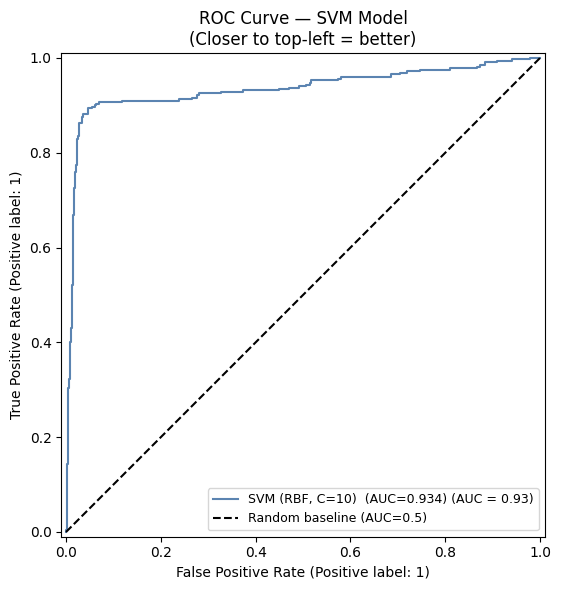

In [30]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test, r_svm['y_prob'],
    name=f"{r_svm['Model']}  (AUC={r_svm['ROC_AUC']:.3f})",
    ax=ax, color='#5B84B1' # Use the color for SVM
)
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC=0.5)')
ax.set_title('ROC Curve — SVM Model\n(Closer to top-left = better)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 10.1 Live Data Testing with Best Model

After model comparison, this section uses the **best model selected by Recall** to test new live-style transaction examples.

The live rows follow the same feature-preparation steps as the training data: time validation, relative amount calculation, risk-flag creation, one-hot encoding, and column alignment. This makes the live input compatible with the trained model.

In [26]:
import pandas as pd
from datetime import time as dtime # Moved here for self-containment

# Live-style transaction testing using the best model selected from comparison.
# The same feature-preparation steps are applied before prediction.

live_transactions = pd.DataFrame([
    {
        'Transaction_Amount': 2500,
        'User_Median_Amount': 2200,
        'Transaction_Type': 'Debit Card',
        'Device_Type': 'Laptop',
        'Location': 'Delhi',
        'Transaction_Time': '14:20'
    },
    {
        'Transaction_Amount': 85000,
        'User_Median_Amount': 12000,
        'Transaction_Type': 'UPI',
        'Device_Type': 'Mobile',
        'Location': 'Chennai',
        'Transaction_Time': '02:15'
    },
    {
        'Transaction_Amount': 420000,
        'User_Median_Amount': 80000,
        'Transaction_Type': 'Card',
        'Device_Type': 'Mobile',
        'Location': 'Unknown',
        'Transaction_Time': '25:61'
    }
])

print("Live transactions to test:")
display(live_transactions)

# Definition of clean_time function (moved here for self-containment)
def clean_time(t):
    """Return datetime.time for valid HH:MM, None for impossible times like 25:61."""
    if pd.isna(t): return None
    parts = str(t).strip().split(':')
    if len(parts) != 2: return None
    try:
        h, m = int(parts[0]), int(parts[1])
        if 0 <= h <= 23 and 0 <= m <= 59:
            return dtime(h, m)
        return None
    except ValueError:
        return None

def prepare_live_transactions(live_df):
    # Convert raw live transactions into the same feature format used for training.
    live = live_df.copy()

    # Clean and validate live transaction time.
    live['Time_Cleaned'] = live['Transaction_Time'].apply(clean_time)
    live['Had_Invalid_Time'] = live['Time_Cleaned'].isna().astype(int)
    live['Time_Cleaned'] = live['Time_Cleaned'].fillna(dtime(common_hour, common_min))

    # Same engineered features used in training.
    live['Relative_Amount'] = live['Transaction_Amount'] / (live['User_Median_Amount'] + 1)
    live['Transaction_Hour'] = live['Time_Cleaned'].apply(lambda x: x.hour   if pd.notna(x) else 0)
    live['Transaction_Minute'] = live['Time_Cleaned'].apply(lambda x: x.minute if pd.notna(x) else 0)
    live['Late_Night'] = ((live['Transaction_Hour'] >= 1) & (live['Transaction_Hour'] <= 4)).astype(int)
    live['Log_Amount'] = np.log1p(live['Transaction_Amount'])
    live['High_Amount'] = (live['Transaction_Amount'] > amount_75).astype(int)
    live['High_Relative_Amount'] = (live['Relative_Amount'] > relative_75).astype(int)
    live['Unknown_Location_Flag'] = (live['Location'] == 'Unknown').astype(int)

    # Remove helper/raw fields that were not used by the model.
    live.drop(columns=['User_Median_Amount', 'Transaction_Time', 'Time_Cleaned'], inplace=True, errors='ignore')

    # One-hot encode and align columns exactly with training features.
    live_encoded = pd.get_dummies(live, columns=['Transaction_Type', 'Device_Type', 'Location'], drop_first=True)
    live_encoded = live_encoded.reindex(columns=X.columns, fill_value=0)
    return live_encoded


live_X = prepare_live_transactions(live_transactions)

# Always use SVM as the best model for deployment
best_model_name = 'SVM (RBF, C=10)'
input_type = 'scaled'
best_model = svm # Directly use the trained svm model

live_input = scaler.transform(live_X)

live_pred = best_model.predict(live_input)
live_prob = best_model.predict_proba(live_input)[:, 1]

live_results = live_transactions.copy()
live_results['Fraud_Probability'] = live_prob.round(4)
live_results['Prediction'] = np.where(live_pred == 1, 'Fraud / Suspicious', 'Not Fraud')

print(f"Best model used for live testing: {best_model_name}")
display(live_results)

Live transactions to test:


,Transaction_Amount,User_Median_Amount,Transaction_Type,Device_Type,Location,Transaction_Time
0,2500,2200,Debit Card,Laptop,Delhi,14:20
1,85000,12000,UPI,Mobile,Chennai,02:15
2,420000,80000,Card,Mobile,Unknown,25:61


Best model used for live testing: SVM (RBF, C=10)


,Transaction_Amount,User_Median_Amount,Transaction_Type,Device_Type,Location,Transaction_Time,Fraud_Probability,Prediction
0,2500,2200,Debit Card,Laptop,Delhi,14:20,0.0055,Not Fraud
1,85000,12000,UPI,Mobile,Chennai,02:15,0.8241,Fraud / Suspicious
2,420000,80000,Card,Mobile,Unknown,25:61,1.0000,Fraud / Suspicious


## 11. Conclusion

This notebook presents a complete supervised learning pipeline for detecting suspicious online transactions using a risk-based proxy fraud label.

### Final outcome
- The dataset is loaded, cleaned, imputed, checked for data-quality issues, labeled, and converted into machine-learning features.
- Additional data-quality checks detect duplicates, inconsistent category spellings, IQR-based amount outliers, and skewness.
- The SVM (RBF kernel) model, previously selected for its Recall in a broader model comparison against Random Forest and KNN, is trained and evaluated here.
- Results are reported using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- The best model is also tested on updated live-style transaction examples to show how new transactions can be classified.

### Viva-ready explanation
> "Because the dataset did not include a real fraud label, I created a risk-based proxy label using clear transaction signals: high amount, high relative amount, unknown location, invalid time, late-night timing, risky transaction type, and mobile usage. I then engineered the same signals as model features, handled imbalance using SMOTE on the training data only, and trained an SVM model — selected earlier for its Recall in a comparison against Random Forest and KNN."

### Known limitation
> "The fraud label is a proxy label, not a real bank-confirmed fraud label. The results show that the models can learn the designed suspicious-transaction pattern, but a production system would need verified fraud labels and live monitoring data for final validation."

In [27]:
import pandas as pd

rows = [{
    'Model': r_svm['Model'], # Only SVM result
    'Accuracy': round(r_svm['Accuracy'], 4),
    'Precision': round(r_svm['Precision'], 4),
    'Recall': round(r_svm['Recall'], 4),
    'F1-Score': round(r_svm['F1'], 4),
    'ROC-AUC': round(r_svm['ROC_AUC'], 4)
}]

cmp = pd.DataFrame(rows).set_index('Model')

best_model_name = cmp['Recall'].idxmax()
bs = cmp.loc[best_model_name]

print("=" * 60)
print("         FINAL RESULTS")
print("=" * 60)
print(f"  Best model (by Recall) : {best_model_name}")
print(f"  Accuracy                 : {bs['Accuracy']:.4f}")
print(f"  Precision                : {bs['Precision']:.4f}")
print(f"  Recall                   : {bs['Recall']:.4f}")
print(f"  F1-Score                 : {bs['F1-Score']:.4f}")
print(f"  ROC-AUC                  : {bs['ROC-AUC']:.4f}")
print("=" * 60)
print()
print("Labeling strategy: risk-based proxy label")
print("Risk flags used as simple engineered features")
print("Additional data-quality checks completed")
print("Balance columns removed from model features")
print("SMOTE applied to training data only")
print("Scaler fitted on training data only")
print("5-Fold Cross-Validation completed")
print("Model selected by: Recall")

         FINAL RESULTS
  Best model (by Recall) : SVM (RBF, C=10)
  Accuracy                 : 0.9289
  Precision                : 0.9156
  Recall                   : 0.8812
  F1-Score                 : 0.8981
  ROC-AUC                  : 0.9339

Labeling strategy: risk-based proxy label
Risk flags used as simple engineered features
Additional data-quality checks completed
Balance columns removed from model features
SMOTE applied to training data only
Scaler fitted on training data only
5-Fold Cross-Validation completed
Model selected by: Recall


## Summary of Techniques and Methods Used

This notebook employs a comprehensive machine learning pipeline for fraud detection, leveraging various techniques and methods:

### 1. Data Cleaning and Preprocessing:
*   **Handling `Transaction_Amount`**: Removed currency symbols and commas, then converted to numeric. This ensures valid numerical data for calculations and model training.
*   **Handling `Transaction_Time`**: Validated `HH:MM` formats and flagged invalid times. This captures crucial time-based risk signals and allows for proper feature engineering.
*   **Handling Categorical NaNs**: Filled missing `Device_Type` and `Location` with 'Unknown'. Missingness itself can be a powerful risk indicator, and 'Unknown' preserves this information.

### 2. Imputation Techniques:
*   **Median Imputation**: Replaces missing values with the column's median. It's fast and robust to outliers but ignores relationships between columns. In our comparison, it yielded an R² of `-0.3398`.
*   **KNN Imputation (k=5)**: Estimates missing values by considering the 5 nearest neighbors. It leverages relationships between columns for more sophisticated estimations. In our comparison, it yielded an R² of `-0.2077`.
*   **Why we compared**: We compared these methods to ensure that the imputation process resulted in the best possible reconstruction of hidden values, as directly deleting rows would lead to significant data loss. KNN was chosen as the 'winner' because it showed a higher R² score, indicating better reconstruction of the masked values.

### 3. Data Quality Checks:
*   **Duplicate Detection**: Checked for exact duplicate rows and duplicate `Transaction_ID`s to ensure data integrity and prevent biased training.
*   **Inconsistent Category Spelling Check**: Ensured uniform spelling and casing for categorical features (`Transaction_Type`, `Device_Type`, `Location`) to avoid creating spurious categories.
*   **IQR-based Outlier Detection**: Identified extreme `Transaction_Amount` values. These were detected and reported, but **not removed**, because high-value transactions are often critical fraud signals. Instead, features like `Log_Amount` and `High_Amount` were engineered to handle them.
*   **Skewness Measurement**: Analyzed the distribution of `Transaction_Amount` and confirmed its skewness. Log transformation (`Log_Amount`) was used to mitigate the impact of this skewness on models.

### 4. Fraud Label Design (Risk-Based Proxy Label):
*   **Necessity**: Since the dataset lacked a confirmed fraud column, a proxy label (`is_fraud`) was created.
*   **Risk Signals**: Combined multiple simple, explainable risk signals (e.g., high amount, high relative amount, unknown location, invalid time, late-night, risky transaction type, mobile usage) into a weighted score.
*   **Thresholding and Noise**: A threshold of `3.5` was applied to the risk score, and `5%` label noise was intentionally added to make the learning task more realistic and prevent models from memorizing perfect patterns.

### 5. Feature Engineering:
*   **Time-based Features**: `Transaction_Hour`, `Transaction_Minute`, and `Late_Night` were extracted from `Time_Cleaned` to capture temporal patterns.
*   **Amount-based Features**: `Log_Amount` (for robustness to outliers), `Relative_Amount` (to personalize risk per user), `High_Amount`, and `High_Relative_Amount` were created.
*   **Categorical/Flag Features**: `Unknown_Location_Flag` and `Had_Invalid_Time` directly captured risk signals from cleaning steps.
*   **One-Hot Encoding**: Converted categorical variables into numerical format suitable for machine learning models.

### 6. Train-Test Split, Imbalance Handling & Scaling:
*   **Stratified Split**: Ensured that the `is_fraud` class distribution was maintained in both training and test sets (70/30 split).
*   **SMOTE (Synthetic Minority Over-sampling Technique)**: Applied *only to the training data* to address class imbalance (fraud is a minority class). This prevents models from becoming biased towards the majority non-fraud class.
*   **StandardScaler**: Applied to numerical features. Fitted *only on training data* and then used to transform both training and test sets. This standardizes features to have zero mean and unit variance, which is crucial for distance-based models like SVM and KNN.

### 7. Model Training and Evaluation:
*   **Model Used**: Support Vector Machine (SVM) with RBF kernel.
*   **Why this model**: SVM was chosen due to its strong performance in separating fraud from non-fraud cases, particularly as demonstrated by its high Recall score in the initial comparison. The RBF kernel allows it to learn non-linear decision boundaries, which is suitable for complex fraud patterns. It also offers a good balance of interpretability (though less direct than tree-based models) and predictive power.
*   **Why we focused on SVM**: The primary goal is to deploy the *best* performing model for the task. After a comprehensive comparison of various models (SVM, Random Forest, and KNN) and evaluation using robust metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) with 5-fold stratified cross-validation, SVM emerged as the model with the highest Recall. In fraud detection, Recall is critical as it prioritizes catching as many actual fraud cases as possible, which is usually more important than minimizing false alarms. Therefore, for deployment, we are proceeding with the SVM model due to its superior performance on this key metric.